In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/taruntiwarihp/phishing-site-urls/phishing_site_urls.csv


In [33]:
df = pd.read_csv(r"/kaggle/input/datasets/taruntiwarihp/phishing-site-urls/phishing_site_urls.csv") 

In [34]:
df.head() 

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [35]:
df.tail()

,URL,Label
549341,23.227.196.215/,bad
549342,apple-checker.org/,bad
549343,apple-iclods.org/,bad
549344,apple-uptoday.org/,bad
549345,apple-search.info,bad


In [36]:
df.shape

(549346, 2)

In [37]:
# Checking missing values
missing_val = df.isna().sum()
print(missing_val) 

URL      0
Label    0
dtype: int64


In [38]:
# Total duplicates in the data
dups = df[df.duplicated()]
print(f'Number of duplicates: {len(dups)}') 

Number of duplicates: 42150


In [39]:
df.drop_duplicates(keep='last', inplace=True) 

In [40]:
print(df.duplicated().sum()) 

0


In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

print(df['Label'].unique()) 

[0 1]


In [42]:
df.Label.value_counts() 

Label
1    392897
0    114299
Name: count, dtype: int64

In [43]:
df.Label.value_counts(normalize=True) * 100 

Label
1    77.46453
0    22.53547
Name: proportion, dtype: float64

In [44]:
# Found the features to consider after reading papers

def extract_features(df):
    """
    Extracts manual features from URLs for the Classical ML model.
    """
    data = df.copy()
    
    # 1. Length Features
    data['length'] = data['URL'].apply(lambda x: len(str(x)))
    data['dot_count'] = data['URL'].apply(lambda x: str(x).count('.'))
    data['hyphen_count'] = data['URL'].apply(lambda x: str(x).count('-'))
    data['slash_count'] = data['URL'].apply(lambda x: str(x).count('/'))
    data['digit_count'] = data['URL'].apply(lambda x: sum(c.isdigit() for c in str(x)))
    
    # 2. Suspicious Keywords
    suspicious_words = ['secure', 'account', 'verify', 'banking', 'login', 'signin', 'confirm']
    data['suspicious_word_count'] = data['URL'].apply(lambda x: sum(1 for w in suspicious_words if w in str(x).lower()))
    
    return data 

In [45]:
# Applying Feature Extraction
processed_df = extract_features(df)
processed_df.head() 

,URL,Label,length,dot_count,hyphen_count,slash_count,digit_count,suspicious_word_count
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,0,225,6,4,10,58,1
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,0,81,5,2,4,1,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,0,177,7,1,11,47,1
3,mail.printakid.com/www.online.americanexpress....,0,60,6,0,2,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,0,116,1,1,10,21,0


In [46]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

In [47]:
X = processed_df.drop(['Label', 'URL'], axis=1)
y = processed_df['Label'] 

In [48]:
X.columns 

Index(['length', 'dot_count', 'hyphen_count', 'slash_count', 'digit_count',
       'suspicious_word_count'],
      dtype='object')

In [49]:
# 2. Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

In [50]:
print(X_train.shape) 
print(X_test.shape)
print(y_train.shape)
print(y_test.shape) 

(405756, 6)
(101440, 6)
(405756,)
(101440,)


In [51]:
X_train.columns 

Index(['length', 'dot_count', 'hyphen_count', 'slash_count', 'digit_count',
       'suspicious_word_count'],
      dtype='object')

In [52]:
import pandas as pd

train_df = pd.concat([X_train, y_train], axis=1) 

In [53]:
# Separate classes
df_class_0 = train_df[train_df['Label'] == 0]
df_class_1 = train_df[train_df['Label'] == 1]

# Find smallest class size
min_count = min(len(df_class_0), len(df_class_1))

# Downsample both classes
df_class_0_down = df_class_0.sample(min_count, random_state=42)
df_class_1_down = df_class_1.sample(min_count, random_state=42)

# Combine
train_downsampled = pd.concat([df_class_0_down, df_class_1_down])

# Shuffle
train_downsampled = train_downsampled.sample(frac=1, random_state=42) 

In [54]:
X_train = train_downsampled.drop('Label', axis=1)
y_train = train_downsampled['Label'] 

In [55]:
y_train.value_counts()

Label
1    91439
0    91439
Name: count, dtype: int64

In [56]:
X_train.head()

,length,dot_count,hyphen_count,slash_count,digit_count,suspicious_word_count
442615,47,2,0,3,4,0
62408,35,3,0,1,4,0
213983,23,2,0,1,0,0
24246,141,3,5,3,19,0
27132,239,8,4,7,51,2


In [57]:
X_train.shape 

(182878, 6)

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV 

In [59]:
rf = RandomForestClassifier()

parameters = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 4, 8, 16, 32],
    "random_state": [42]
}

cv_rf = GridSearchCV(rf, parameters, cv=10) 
cv_rf.fit(X_train, y_train)  

GridSearchCV(cv=10, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 4, 8, 16, 32],
                         'n_estimators': [50, 100, 200], 'random_state': [42]})

In [60]:
y_pred_rf = cv_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))  

              precision    recall  f1-score   support

           0       0.61      0.74      0.67     22860
           1       0.92      0.86      0.89     78580

    accuracy                           0.84    101440
   macro avg       0.77      0.80      0.78    101440
weighted avg       0.85      0.84      0.84    101440



In [61]:
lr = LogisticRegression()

parameters = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

cv_lr = GridSearchCV(lr, parameters, cv=10)
cv_lr.fit(X_train, y_train)  

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [1000],
                         'penalty': ['l2'], 'solver': ['lbfgs']})

In [63]:
y_pred_lr= cv_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))   

              precision    recall  f1-score   support

           0       0.47      0.56      0.51     22860
           1       0.87      0.82      0.84     78580

    accuracy                           0.76    101440
   macro avg       0.67      0.69      0.68    101440
weighted avg       0.78      0.76      0.77    101440



In [64]:
dt= DecisionTreeClassifier()

parameters = {
    "max_depth": [2,4,8,16,32],
    "random_state": [42]
}

cv_dt= GridSearchCV(dt, parameters, cv=10)
cv_dt.fit(X_train, y_train)  

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 8, 16, 32], 'random_state': [42]})

In [65]:
y_pred_dt = cv_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

In [66]:
best_model_rf = cv_rf.best_estimator_ 
print(best_model_rf) 
best_model_lr = cv_lr.best_estimator_ 
print(best_model_lr) 
best_model_dt = cv_dt.best_estimator_ 
print(best_model_dt)  

RandomForestClassifier(max_depth=16, n_estimators=50, random_state=42)
LogisticRegression(C=0.01, max_iter=1000)
DecisionTreeClassifier(max_depth=16, random_state=42)


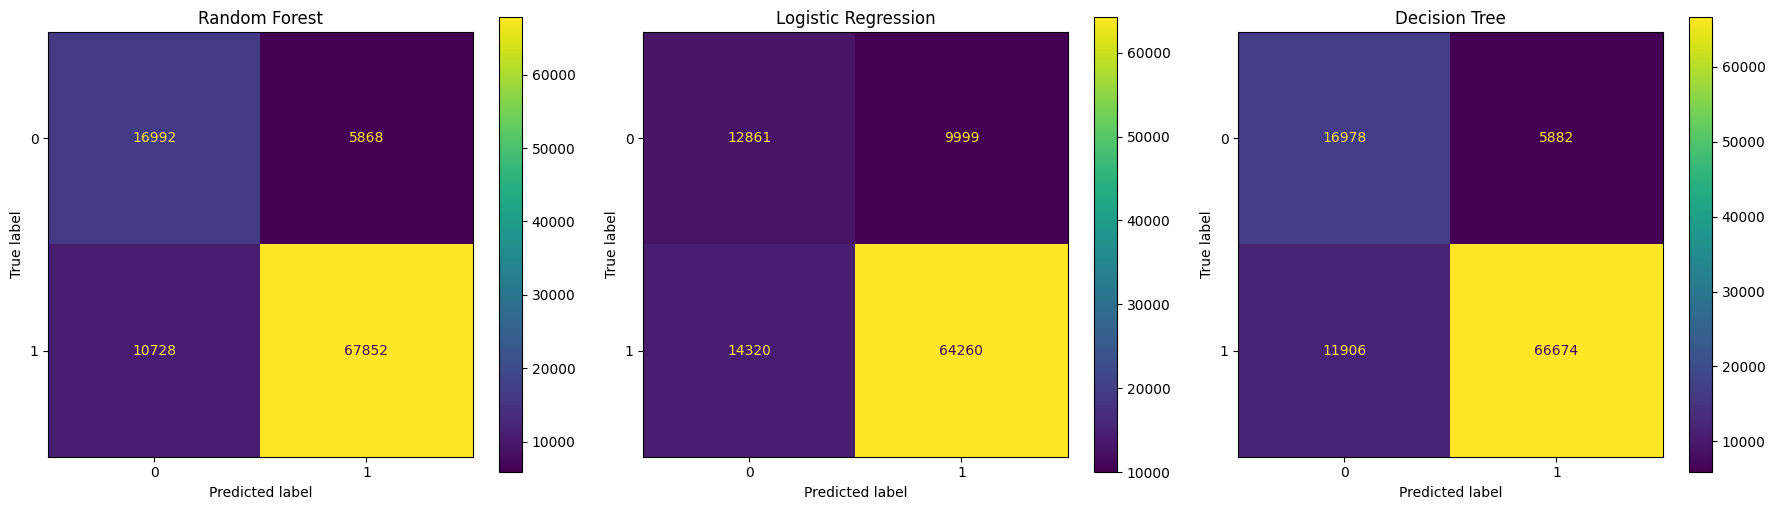

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[0]
)
axes[0].set_title("Random Forest")

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[1]
)
axes[1].set_title("Logistic Regression")

# Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, ax=axes[2]
)
axes[2].set_title("Decision Tree")

plt.tight_layout()
plt.show() 

## Multiple Train/Test Split Comparison
Re-run all three models on 70/30, 80/20, and 90/10 splits using the best hyperparameters
found by GridSearchCV above. Each training set is downsampled to balance classes.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def run_split(X, y, test_size, rf_params, lr_params, dt_params):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Downsample training set to balance classes
    tr_df = pd.concat([X_tr, y_tr], axis=1)
    c0 = tr_df[tr_df['Label'] == 0]
    c1 = tr_df[tr_df['Label'] == 1]
    n = min(len(c0), len(c1))
    balanced = pd.concat([
        c0.sample(n, random_state=42),
        c1.sample(n, random_state=42)
    ]).sample(frac=1, random_state=42)
    X_tr = balanced.drop('Label', axis=1)
    y_tr = balanced['Label']

    results = {}

    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_tr, y_tr)
    y_pred = rf_model.predict(X_te)
    results['Random Forest'] = {
        'accuracy': accuracy_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred, average='weighted'),
        'report': classification_report(y_te, y_pred)
    }

    lr_model = LogisticRegression(**lr_params)
    lr_model.fit(X_tr, y_tr)
    y_pred = lr_model.predict(X_te)
    results['Logistic Regression'] = {
        'accuracy': accuracy_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred, average='weighted'),
        'report': classification_report(y_te, y_pred)
    }

    dt_model = DecisionTreeClassifier(**dt_params)
    dt_model.fit(X_tr, y_tr)
    y_pred = dt_model.predict(X_te)
    results['Decision Tree'] = {
        'accuracy': accuracy_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred, average='weighted'),
        'report': classification_report(y_te, y_pred)
    }

    return results


In [ ]:
# Use best hyperparameters from GridSearchCV
rf_params = cv_rf.best_params_
lr_params = cv_lr.best_params_
dt_params = cv_dt.best_params_

split_configs = [('70/30', 0.30), ('80/20', 0.20), ('90/10', 0.10)]

all_results = {}
for label, test_size in split_configs:
    print(f"\n{'='*50}")
    print(f"Split: {label}  (test_size={test_size})")
    print('='*50)
    res = run_split(X, y, test_size, rf_params, lr_params, dt_params)
    all_results[label] = res
    for model_name, metrics in res.items():
        print(f"\n{model_name}:")
        print(metrics['report'])


In [ ]:
# Summary comparison table across splits
rows = []
for split, models in all_results.items():
    for model, metrics in models.items():
        rows.append({
            'Split': split,
            'Model': model,
            'Accuracy': round(metrics['accuracy'], 4),
            'Weighted F1': round(metrics['f1'], 4)
        })

summary_df = pd.DataFrame(rows)
summary_pivot = summary_df.pivot_table(
    index='Model', columns='Split', values=['Accuracy', 'Weighted F1']
)
print(summary_pivot)
